In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("physical_therapy_visits.csv")

## Basic Exploration

In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Visit_ID                    100000 non-null  object 
 1   Patient_ID                  100000 non-null  object 
 2   Patient_Age                 100000 non-null  int64  
 3   Gender                      100000 non-null  object 
 4   Diagnosis                   100000 non-null  object 
 5   Treatment_Type              100000 non-null  object 
 6   Therapist_ID                100000 non-null  object 
 7   Therapist_Name              100000 non-null  object 
 8   Visit_Date                  100000 non-null  object 
 9   Session_Duration_Min        100000 non-null  int64  
 10  Visits_Completed            100000 non-null  int64  
 11  Pain_Score_Before           100000 non-null  int64  
 12  Pain_Score_After            100000 non-null  int64  
 13  Improvement_Per

Visit_ID                      0
Patient_ID                    0
Patient_Age                   0
Gender                        0
Diagnosis                     0
Treatment_Type                0
Therapist_ID                  0
Therapist_Name                0
Visit_Date                    0
Session_Duration_Min          0
Visits_Completed              0
Pain_Score_Before             0
Pain_Score_After              0
Improvement_Percentage        0
Insurance_Provider            0
Insurance_Coverage_Percent    0
Treatment_Cost                0
Insurance_Payment             0
Patient_Payment               0
Clinic_Location               0
Revenue                       0
Satisfaction_Score            0
dtype: int64

## Revenue Analysis

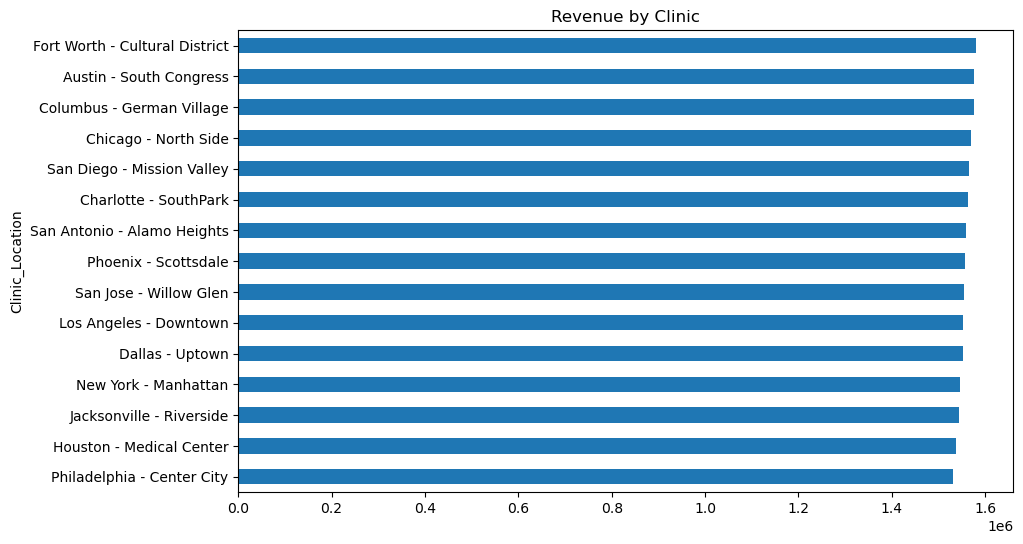

In [4]:
clinic_revenue = df.groupby('Clinic_Location')['Revenue'].sum()

clinic_revenue.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Revenue by Clinic")
plt.show()

## Diagnosis Distribution

<Axes: xlabel='count', ylabel='Diagnosis'>

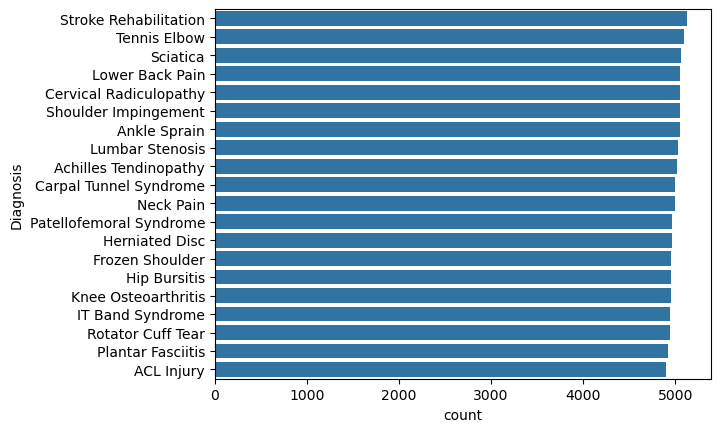

In [5]:
sns.countplot(
    data=df,
    y='Diagnosis',
    order=df['Diagnosis'].value_counts().index
)

## Improvement Analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Balance Training'),
  Text(1, 0, 'Kinesio Taping'),
  Text(2, 0, 'Ultrasound Therapy'),
  Text(3, 0, 'Post-Surgical Rehab'),
  Text(4, 0, 'Sports Rehabilitation'),
  Text(5, 0, 'Neurological Rehab'),
  Text(6, 0, 'Electrotherapy'),
  Text(7, 0, 'Hydrotherapy'),
  Text(8, 0, 'Gait Training'),
  Text(9, 0, 'Traction Therapy'),
  Text(10, 0, 'Manual Therapy'),
  Text(11, 0, 'Dry Needling'),
  Text(12, 0, 'TENS Therapy'),
  Text(13, 0, 'Heat/Cold Therapy'),
  Text(14, 0, 'Exercise Therapy')])

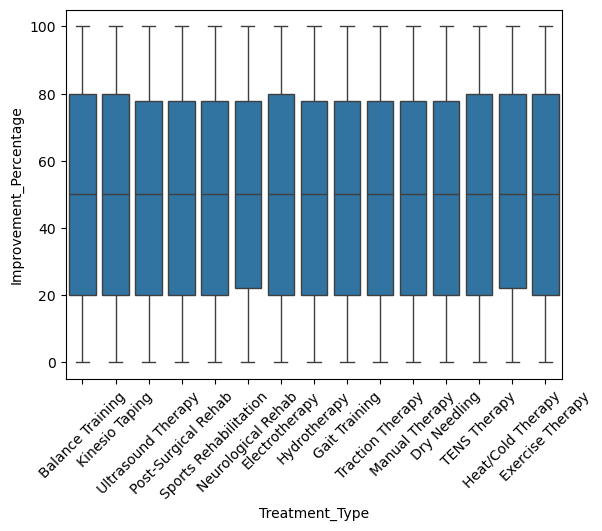

In [6]:
sns.boxplot(
    x='Treatment_Type',
    y='Improvement_Percentage',
    data=df
)

plt.xticks(rotation=45)

## Satisfaction vs Improvement

<Axes: xlabel='Improvement_Percentage', ylabel='Satisfaction_Score'>

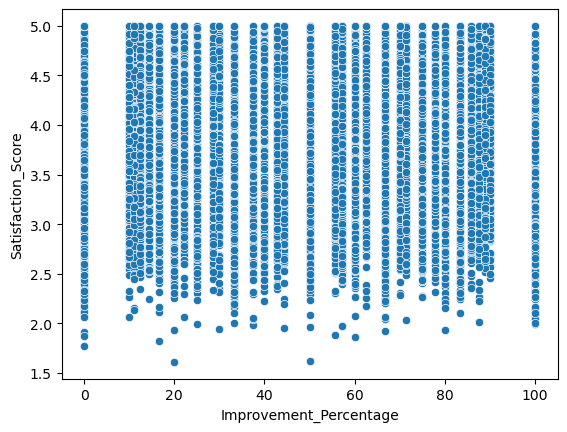

In [7]:
sns.scatterplot(
    data=df,
    x='Improvement_Percentage',
    y='Satisfaction_Score'
)

## Correlation Heatmap

<Axes: >

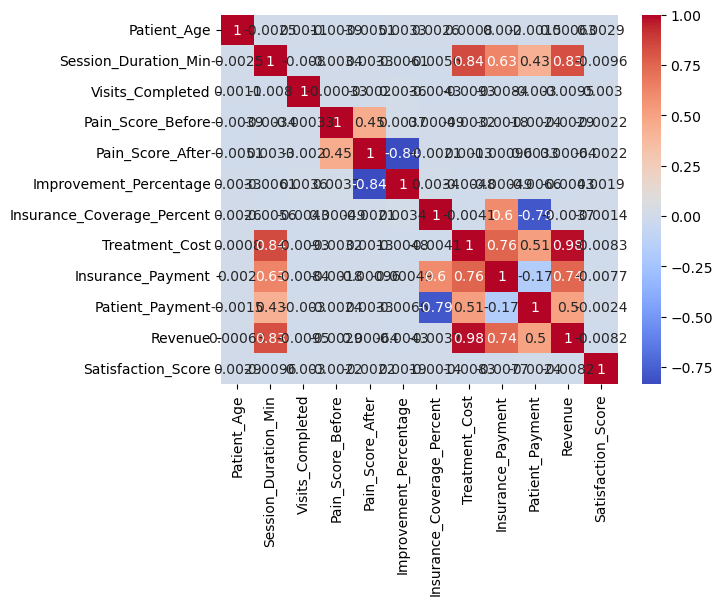

In [8]:
numeric_cols = df.select_dtypes(include='number')

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)